# Lecture 7 Lab — Exploratory Data Analysis
## ITDS341 Fundamentals of Data Science · MUICT

### Business Context

An insurance company has observed rising claim costs over recent years.
Before building any predictive model, the analytics team needs to
**explore the data** to understand policyholder characteristics,
identify patterns, and discover questions worth investigating further.

Your role: conduct a systematic EDA of the insurance dataset and
produce **evidence-based observations** — not conclusions about causation
or predictive importance.

---

### Dataset: `insurance_add_step.csv`

Download from [Google Drive](https://drive.google.com/file/d/1-8y0tWd2ukeIGUJOIqwwhtPBlWScIRhn/view?usp=sharing).

| Feature | Description |
|---|---|
| `age` | Age of policyholder |
| `sex` | Gender (0 = female, 1 = male) |
| `bmi` | Body mass index |
| `steps` | Average walking steps per day |
| `children` | Number of dependents |
| `smoker` | Smoking status (0 = non-smoker, 1 = smoker) |
| `region` | Residential region (0 = NE, 1 = NW, 2 = SE, 3 = SW) |
| `charges` | Individual medical costs billed by insurer |
| `insuranceclaim` | Whether a claim was made (1 = yes, 0 = no) |

**References:**  
Kaggle dataset · Chapter 10 of *Learning Data Science* (Lau, Gonzalez, Nolan — O'Reilly, 2023)

---

### EDA Guiding Questions

Keep these questions in mind throughout the lab:

1. How are policyholders distributed across major characteristics?
2. Which groups show noticeably different claim rates or medical charges?
3. Which numerical variables appear associated with each other?
4. Are there unusual subgroups or values that deserve closer attention?
5. What **cannot** be concluded from EDA alone?


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent style
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)

In [2]:
df = pd.read_csv('insurance_add_step.csv')
df.head()

,age,sex,bmi,steps,children,smoker,region,charges,insuranceclaim
0,19.0,0,27.900,3009.0,0.0,1,southwest,16884.92400,1.0
1,18.0,male,33.770,3008.0,1.0,0,southeast,1725.55230,1.0
2,28.0,male,33.000,3009.0,3.0,0,southeast,4449.46200,0.0
3,33.0,male,22.705,10009.0,NaN,0,northwest,21984.47061,0.0
4,32.0,male,28.880,8010.0,NaN,0,northwest,3866.85520,1.0


---
## Part 0 — Quick Data Readiness Check

Before visualising anything, confirm the data is ready to explore.
Answer four basic questions: shape, types, missing values, basic ranges.


In [3]:
# Shape: how many rows and columns?
print('Shape:', df.shape)

Shape: (1344, 9)


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1339 non-null   float64
 1   sex             1344 non-null   object 
 2   bmi             1344 non-null   float64
 3   steps           1331 non-null   float64
 4   children        1240 non-null   float64
 5   smoker          1344 non-null   int64  
 6   region          1344 non-null   object 
 7   charges         1342 non-null   float64
 8   insuranceclaim  1342 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 94.6+ KB


In [5]:
# Missing values per column
df.isna().sum()

age                 5
sex                 0
bmi                 0
steps              13
children          104
smoker              0
region              0
charges             2
insuranceclaim      2
dtype: int64

In [6]:
# Basic statistics for all columns
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1339.0,NaN,NaN,NaN,39.222554,14.073363,18.0,26.5,39.0,51.0,64.0
sex,1344,5,male,517,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1344.0,NaN,NaN,NaN,30.659446,6.093595,15.96,26.30875,30.38,34.68125,53.13
steps,1331.0,NaN,NaN,NaN,5358.09692,2456.921349,2908.0,3009.0,4007.0,8004.0,10010.0
children,1240.0,NaN,NaN,NaN,1.185484,1.209773,0.0,0.0,1.0,2.0,5.0
smoker,1344.0,NaN,NaN,NaN,0.203869,0.403023,0.0,0.0,0.0,0.0,1.0
region,1344,4,southeast,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1342.0,NaN,NaN,NaN,13265.80805,12098.073122,1121.8739,4740.28715,9382.033,16639.912515,63770.42801
insuranceclaim,1342.0,NaN,NaN,NaN,0.584948,0.492915,0.0,0.0,1.0,1.0,1.0


**Task 0 — Data Readiness**

Answer the following before moving on:

1. Are there any missing values? If yes, which columns and how many?
2. Does `df.describe()` reveal any values that seem impossible or suspicious
   (e.g., negative charges, BMI of 0)?
3. Based on `df.info()`, which columns have a numeric dtype but are actually
   categorical in meaning? List them.

> Only fix what blocks exploration. This is not another cleaning lab.


**YOUR ANSWER HERE**
1. There are missing values in the dataset (age - 5, steps - 13, children - 104, charges - 2, insuranceclaim - 2).
2. The `df.describe()` output does not reveal any impossible or suspicious values. All values appear to be within reasonable ranges for their respective features.
3. The columns `sex`, `smoker`, and `insuranceclaim` have a numeric dtype but are actually categorical in meaning.

---
## Part 1 — Feature Type Classification

Feature type determines what summaries and plots are meaningful.

> ⚠️ **Key idea:** `dtype` ≠ analytical feature type.  
> A column stored as `int64` may be categorical (e.g., `sex = 0/1`).  
> Always check the data dictionary and observed values together.


In [7]:
# Use these tools to inspect each column — don't rely on dtype alone
print('dtypes:')
print(df.dtypes)
print()
print('unique value counts:')
print(df.nunique())

dtypes:
age               float64
sex                object
bmi               float64
steps             float64
children          float64
smoker              int64
region             object
charges           float64
insuranceclaim    float64
dtype: object

unique value counts:
age                 47
sex                  5
bmi                548
steps               56
children             6
smoker               2
region               4
charges           1337
insuranceclaim       2
dtype: int64


In [8]:
# Inspect individual columns where the type is ambiguous
for col in ['sex', 'smoker', 'region', 'insuranceclaim', 'children']:
    print(f'{col}: {sorted(df[col].unique())}')

sex: ['0', '1', '11', 'female', 'male']
smoker: [np.int64(0), np.int64(1)]
region: ['northeast', 'northwest', 'southeast', 'southwest']
insuranceclaim: [np.float64(0.0), np.float64(nan), np.float64(1.0)]
children: [np.float64(0.0), np.float64(1.0), np.float64(3.0), np.float64(nan), np.float64(2.0), np.float64(4.0), np.float64(5.0)]


**Task 1 — Classify Feature Types**

Complete the table using the data dictionary, `dtype`, `nunique()`,
and `value_counts()` as supporting evidence.
Explain your reasoning for any case where dtype alone could mislead.

| Feature | dtype | Analytical Type | Reasoning |
|---|---|---|---|
| `age` | | | |
| `sex` | | | |
| `bmi` | | | |
| `steps` | | | |
| `children` | | | |
| `smoker` | | | |
| `region` | | | |
| `charges` | | | |
| `insuranceclaim` | | | |

Possible types: *numerical – continuous*, *numerical – discrete*,
*categorical – nominal*, *categorical – ordinal*


**YOUR ANSWER HERE**
| Feature | dtype | Analytical Type | Reasoning |
|---|---|---|---|
| `age` | float64 | numerical – continuous | Age is a continuous variable that can take any value within a range |
| `sex` | object | categorical – nominal | Sex is a categorical variable with distinct categories (e.g., male, female) |
| `bmi` | float64 | numerical – continuous | BMI is a continuous variable that can take any value within a range |
| `steps` | int64 | numerical – discrete | Steps is a count of discrete events (number of steps taken) |
| `children` | int64 | numerical – discrete | Number of children is a count of discrete entities |
| `smoker` | object | categorical – nominal | Smoker status is a categorical variable with distinct categories (e.g., yes, no) |
| `region` | object | categorical – nominal | Region is a categorical variable with distinct categories (e.g., northeast, northwest) |
| `charges` | float64 | numerical – continuous | Charges is a continuous variable that can take any value within a range |
| `insuranceclaim` | object | categorical – nominal | Insurance claim status is a categorical variable with distinct categories (e.g., yes, no) |

---
## Part 2 — Univariate EDA

Explore **one variable at a time**.
For each variable ask: *How is it distributed?
Are there unusual values, gaps, or asymmetry?*

### Checklist for numerical distributions

Every time you interpret a histogram or box plot, address:

| Aspect | What to look for |
|---|---|
| **Shape** | Symmetric? Skewed? Single mode or multiple? |
| **Center** | Where is the bulk of the data? |
| **Spread** | Wide or narrow range? |
| **Gaps** | Any empty regions? |
| **Unusual values** | Isolated points, extreme values? |


### 2.1 Categorical Variables

The example below shows how to explore a categorical variable
using a frequency table and a bar chart together.


In [9]:
# Example: distribution of smoker status
print(df['smoker'].value_counts())
print()
print(df['smoker'].value_counts(normalize=True).round(3))  # proportions

smoker
0    1070
1     274
Name: count, dtype: int64

smoker
0    0.796
1    0.204
Name: proportion, dtype: float64


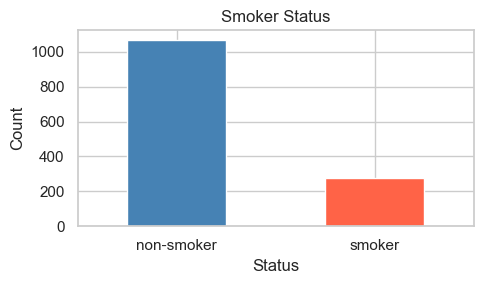

In [10]:
fig, ax = plt.subplots(figsize=(5, 3))
df['smoker'].map({0: 'non-smoker', 1: 'smoker'}).value_counts().plot.bar(
    ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Smoker Status')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show(); plt.close('all')

**Task 2 — Explore Categorical Variables**

Produce a frequency table **and** a bar chart for each of these variables:
`sex`, `region`, `insuranceclaim`, `children`

For each one, write 1–2 sentences describing:
- How are values distributed across categories?
- Is the distribution balanced or skewed toward one group?



--- Frequency Table for sex ---


,count
sex,
male,517
female,502
0,162
1,161
11,2


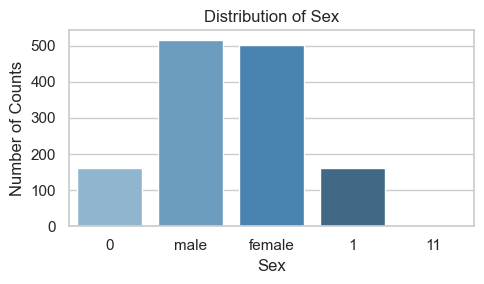


--- Frequency Table for region ---


,count
region,
southeast,365
northwest,328
northeast,326
southwest,325


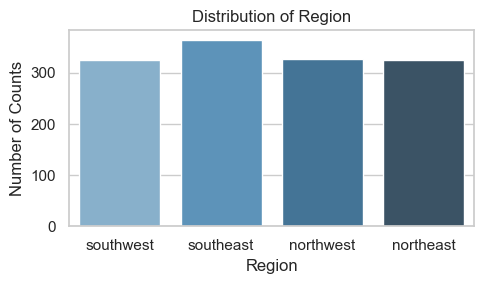


--- Frequency Table for insuranceclaim ---


,count
insuranceclaim,
1.0,785
0.0,557


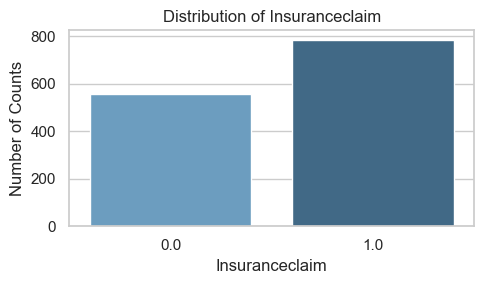


--- Frequency Table for children ---


,count
children,
0.0,473
1.0,325
2.0,242
3.0,157
4.0,25
5.0,18


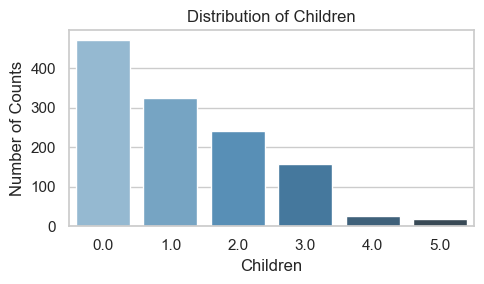

In [11]:
# YOUR CODE HERE — Task 2
# Tip: use .value_counts() for the table, .plot.bar() or sns.countplot() for the chart
variables = ["sex", "region", "insuranceclaim", "children"]

for var in variables:
    counts = df[var].value_counts()
    print(f"\n--- Frequency Table for {var} ---")
    display(counts.to_frame("count"))

    fig, ax = plt.subplots(figsize=(5, 3))
    
    sns.countplot(data=df, x=var, ax=ax, palette="Blues_d")

    ax.set_title(f"Distribution of {var.capitalize()}")
    ax.set_xlabel(var.capitalize())
    ax.set_ylabel("Number of Counts")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

**YOUR INTERPRETATION HERE** (one paragraph per variable)
- How are values distributed across categories? <br>
Sex is balanced between male and female but there's a numerical data appeared, Region is balanced between each regions, Insuranceclaim is skewed toward claimed 1.0 (left), and Children is skewed right with 0.0 is the most frequent value.

- Is the distribution balanced or skewed toward one group? <br>
Sex, Region, are balanced but Insuranceclaim is skewed toward claimed (left). Children is skewed right.

### 2.2 Numerical Variables

The example below shows how to use a histogram and box plot together.
They reveal different things — use both.


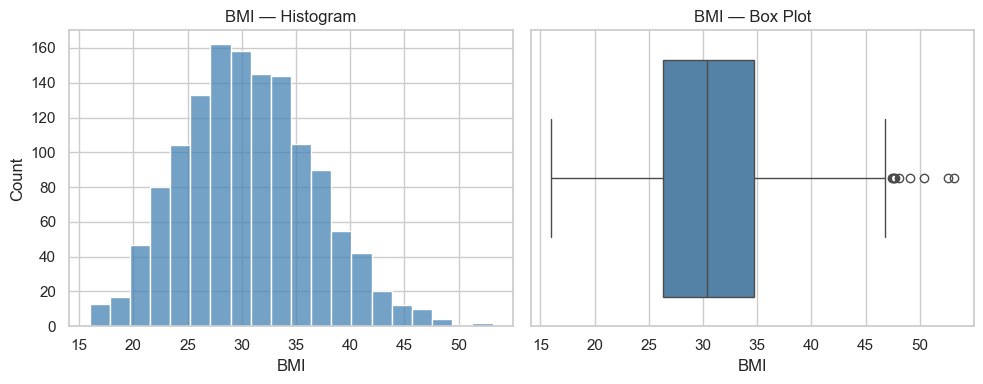

In [12]:
# Example: distribution of BMI
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram — shows shape
sns.histplot(df['bmi'], bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('BMI — Histogram')
axes[0].set_xlabel('BMI')

# Box plot — shows center, spread, and outliers
sns.boxplot(x=df['bmi'], ax=axes[1], color='steelblue')
axes[1].set_title('BMI — Box Plot')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show(); plt.close('all')

In [13]:
# Numerical summary alongside the plots
df['bmi'].describe().round(2)

count    1344.00
mean       30.66
std         6.09
min        15.96
25%        26.31
50%        30.38
75%        34.68
max        53.13
Name: bmi, dtype: float64

**Task 3 — Explore Numerical Variables: `age`, `charges`, `steps`**

For each variable:
1. Create a histogram and a box plot side by side (like the example above).
2. Apply the Shape–Center–Spread–Gaps–Unusual checklist.
3. Explain what each plot reveals that the other does not.

Start with `age`:


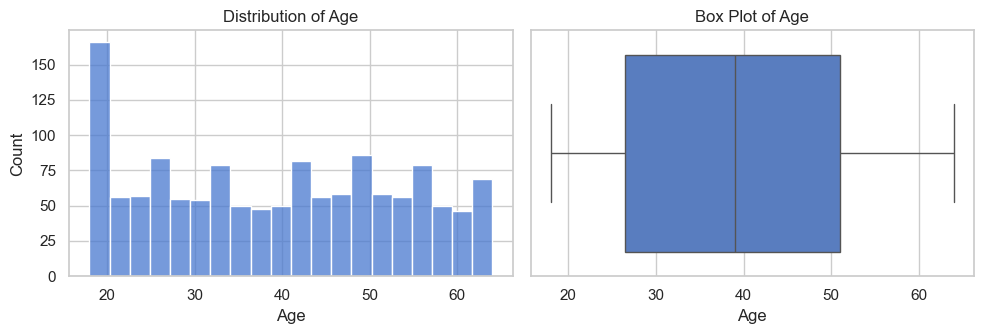

count    1339.00
mean       39.22
std        14.07
min        18.00
25%        26.50
50%        39.00
75%        51.00
max        64.00
Name: age, dtype: float64

In [14]:
# Task 3a: age
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

sns.histplot(data=df, x='age', bins=20, ax=axes[0])
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age")

sns.boxplot(data=df, x='age', ax=axes[1])
axes[1].set_title("Box Plot of Age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

df['age'].describe().round(2)


**Task 3a Interpretation (age):** 
<br>
2. Apply the Shape–Center–Spread–Gaps–Unusual checklist. <br>

Shape: Broadly uniform from ages 21 to 64, but overall skewed by a large single peak at the lower bound (ages 18–20). The box plot masks this multimodal spike and presents as nearly perfectly symmetric.

Center: The median is located at approximately 39 years (dead-center of the box).

Spread:<br>
-Range: Approximately 18 - 65. <br>
-IQR: Approximately (Q1 - 27, Q3 - 51). 

Gaps: None.

Unusual Features: A distinct frequency spike at ages 18–20 (over 160 observations, more than double any other bracket). No outliers appear beyond the whiskers in the box plot.

<br>
3. Explain what each plot reveals that the other does not. <br>
-Histogram reveals the extreme spike at ages 18–20 and multimodal nature of the distribution. <br>
-Box plot shows the overall symmetry of the distribution and highlights the median and IQR, but it does not reveal the multimodal nature of the age distribution.

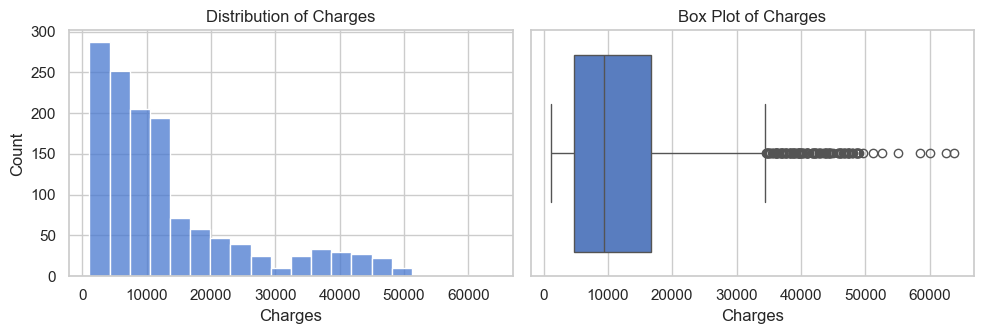

count     1342.00
mean     13265.81
std      12098.07
min       1121.87
25%       4740.29
50%       9382.03
75%      16639.91
max      63770.43
Name: charges, dtype: float64

In [15]:
# Task 3b: charges
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

sns.histplot(data=df, x='charges', bins=20, ax=axes[0])
axes[0].set_title("Distribution of Charges")
axes[0].set_xlabel("Charges")

sns.boxplot(data=df, x='charges', ax=axes[1])
axes[1].set_title("Box Plot of Charges")
axes[1].set_xlabel("Charges")

plt.tight_layout()
plt.show()

df['charges'].describe().round(2)

**Task 3b Interpretation (charges):**

> Hint: `charges` is likely right-skewed. Describe the shape precisely.
> Where is most of the data concentrated? Is there a long upper tail?

Shape: Right-skewed with a long upper tail. The histogram shows a concentration of data at lower charges, with a gradual tapering off as charges increase.
<br>

Data Concentration: Most of the data is concentrated at lower charges (10,000), with a peak around the lower end of the distribution. The box plot confirms this concentration and shows that the median is much lower than the mean, indicating the presence of high-value outliers in the upper tail.


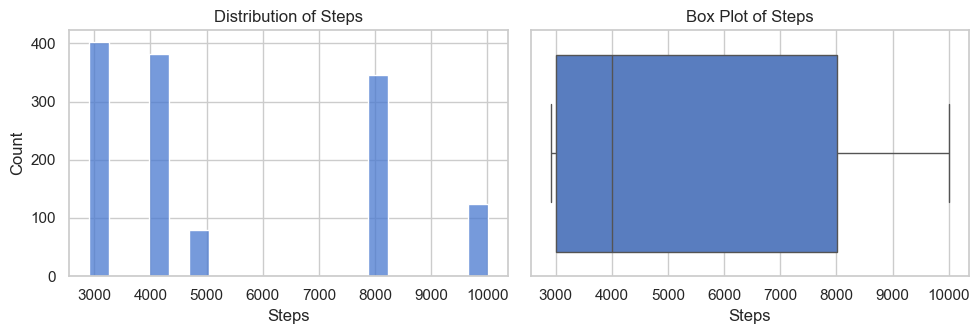

count     1331.00
mean      5358.10
std       2456.92
min       2908.00
25%       3009.00
50%       4007.00
75%       8004.00
max      10010.00
Name: steps, dtype: float64

In [16]:
# Task 3c: steps
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

sns.histplot(data=df, x='steps', bins=20, ax=axes[0])
axes[0].set_title("Distribution of Steps")
axes[0].set_xlabel("Steps")

sns.boxplot(data=df, x='steps', ax=axes[1])
axes[1].set_title("Box Plot of Steps")
axes[1].set_xlabel("Steps")

plt.tight_layout()
plt.show()

df['steps'].describe().round(2)

**Task 3c Interpretation (steps):**

1. Shape–Center–Spread–Gaps–Unusual Checklist:
- **Shape:** Multimodal distribution featuring distinct clusters and peaks around ~3,000, ~4,000, ~8,000, and ~10,000 steps rather than a unimodal or bell-shaped curve.
- **Center:** The median is 4,007.0 steps (mean is ~5,358.1 steps). The median sits in the lower activity tier.
- **Spread:** 
  - Range: ~7,102 steps (Min = 2,908.0, Max = 10,010.0).
  - IQR: ~4,995 steps ($Q_1 \approx 3,009.0$, $Q_3 \approx 8,004.0$).
- **Gaps:** Pronounced gaps exist between the clusters, notably between ~5,000 and 8,000 steps, and between ~8,000 and 10,000 steps.
- **Unusual Features:** Data points clump tightly around specific round-number thresholds (~3,000, ~4,000, ~8,000, ~10,000), likely reflecting discrete activity tracking tiers or milestones. According to the box plot's 1.5 $\times$ IQR rule, there are no statistical outliers beyond the whiskers.

2. What Each Plot Reveals That the Other Does Not:
- **What the Histogram Reveals (Hidden by the Box Plot):** The histogram clearly reveals the multimodal clustering and the empty intervals/gaps between 5,000 and 8,000 steps. The box plot compresses this into a single continuous box and whisker, hiding the multimodality completely.
- **What the Box Plot Reveals (Hidden by the Histogram):** The box plot provides an instant five-number summary (median at 4,007, $Q_1$ at 3,009, $Q_3$ at 8,004) and immediately verifies according to Tukey's fence rule that no individual points are statistical outliers.

---
## Part 3 — Bivariate EDA: Two Numerical Variables

When examining two numerical variables, use a scatter plot and ask:

| Dimension | What to look for |
|---|---|
| **Direction** | Positive, negative, or no trend? |
| **Form** | Linear or curved? |
| **Strength** | Tight cluster or loose scatter? |
| **Unusual** | Any isolated points or subgroups? |


### 3.1 Scatter Plot Example

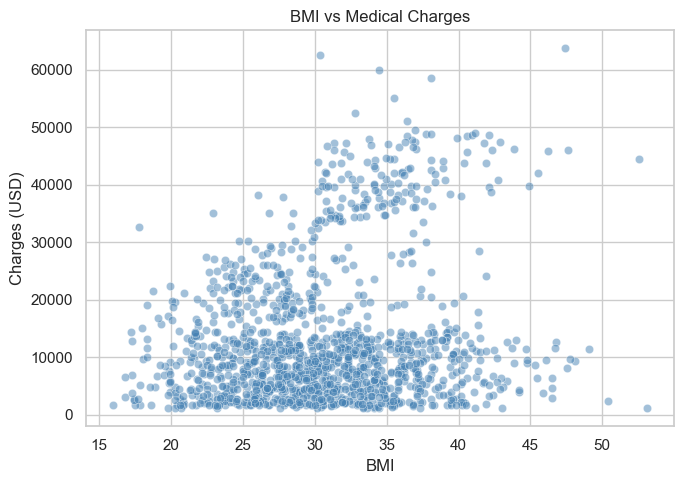

In [17]:
# Example: BMI vs charges
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.5, ax=ax, color='steelblue')
ax.set_title('BMI vs Medical Charges')
ax.set_xlabel('BMI')
ax.set_ylabel('Charges (USD)')
plt.tight_layout()
plt.show(); plt.close('all')

**Task 4 — Scatter Plot: `age` vs `charges`**

1. Create a scatter plot of `age` (x-axis) vs `charges` (y-axis).
2. Describe direction, form, and strength.
3. Do you notice any unusual clusters or subgroups? Describe them.


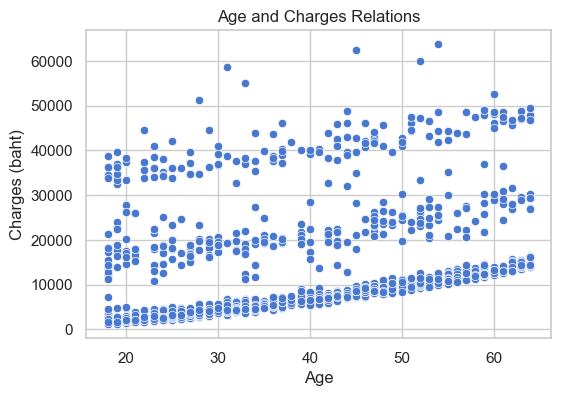

Pearson correlation r = 0.30


In [18]:
# Task 4: age vs charges scatter plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='age', y='charges')
plt.title("Age and Charges Relations")
plt.xlabel("Age")
plt.ylabel("Charges (baht)")
plt.show()

r = df[['age', 'charges']].corr().iloc[0, 1]
print(f"Pearson correlation r = {r:.2f}")

**Task 4 Interpretation:** YOUR ANSWER HERE

* Direction: Positive. As age increases, insurance charges consistently increase across all observation levels.
* Form: Linear. The data points form a clear upward trend, indicating a linear relationship between age and charges.
* Strength: Moderate overall, strong within subgroups.

---

* Unusual Clusters and Subgroups: The scatter plot displays three distinct, upward-sloping bands separated by clear empty gaps:

-Lower Tier (~฿1,000 – ฿15,000):
* Contains the vast majority of the data points.
* Shows an extremely tight, strict linear progression from roughly ฿2,000 at age 18 to ฿15,000 at age 64 with minimal variance (characteristically representing healthy non-smokers).


-Middle Tier (~฿12,000 – ฿30,000+)**:
* Runs parallel to the first band with slightly wider vertical dispersion.
* Starts around ฿12,000–฿20,000 at age 18 and reaches around ฿30,000 at age 64.


-Upper Tier (~฿32,000 – ฿64,000)**:
* Sparsely populated but clearly separated at the top.
* Starts high at around ฿35,000–฿40,000 for young adults and peaks above ฿60,000 for older adults (characteristically representing high-risk individuals, such as smokers with high BMI).


### 3.2 Correlation

Correlation quantifies the **linear** association between two numerical
variables. Before reading any heatmap, recall three important cautions:

> 1. **Correlation ≠ causation.** An association in the data does not tell
>    you why two things move together.
> 2. **Pearson r measures linear association only.** A low r does not mean
>    "no relationship" — the relationship may be curved.
> 3. **Group size matters.** A large group dominates the correlation estimate.


In [19]:
# Correlation matrix (numerical columns only)
corr = df.corr(numeric_only=True).round(2)
corr

,age,bmi,steps,children,smoker,charges,insuranceclaim
age,1.00,0.11,-0.18,0.05,-0.03,0.30,0.12
bmi,0.11,1.00,-0.68,0.01,0.00,0.20,0.39
steps,-0.18,-0.68,1.00,0.06,-0.27,-0.31,-0.43
children,0.05,0.01,0.06,1.00,0.01,0.07,-0.40
smoker,-0.03,0.00,-0.27,0.01,1.00,0.79,0.33
charges,0.30,0.20,-0.31,0.07,0.79,1.00,0.31
insuranceclaim,0.12,0.39,-0.43,-0.40,0.33,0.31,1.00


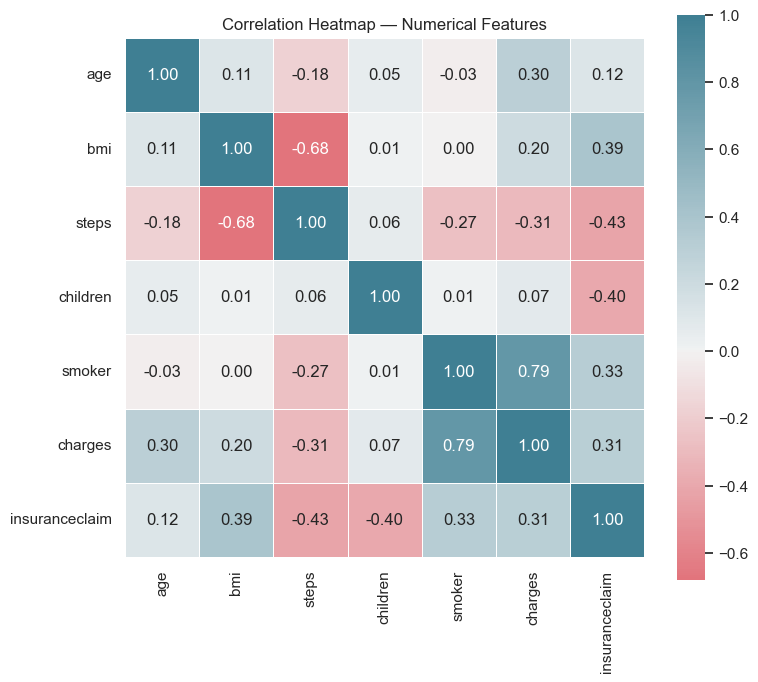

In [20]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr,
    cmap=sns.diverging_palette(h_neg=10, h_pos=220, as_cmap=True),
    center=0, square=True, annot=True, fmt='.2f',
    linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show(); plt.close('all')

**Task 5 — Correlation Analysis**

Identify **two pairs** of variables that show a notable correlation.
For each pair:

1. Report the direction and approximate strength (e.g., "moderate positive, r ≈ 0.30").
2. Create the corresponding scatter plot.
3. Does the scatter plot confirm that the relationship is **linear**?
   Or do you see a curve, clusters, or subgroups?
4. State **one limitation** of using Pearson r for that pair.

> ⚠️ A pattern in the heatmap is a starting point, not a conclusion.
> Always verify with a scatter plot.


Pearson correlation r (age vs charges) = 0.30
Pearson correlation r (bmi vs charges) = 0.20


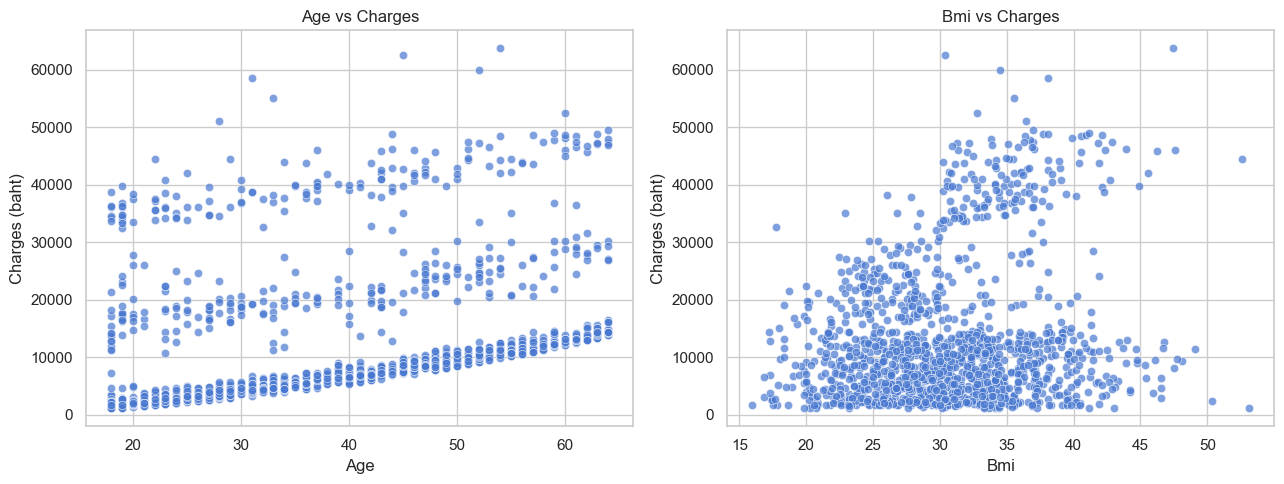

In [21]:
# Task 5: scatter plots for your chosen pairs
# YOUR CODE HERE
pairs = [('age', 'charges'), ('bmi', 'charges')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (x_var, y_var) in zip(axes, pairs):
    sns.scatterplot(data=df, x=x_var, y=y_var, ax=ax, alpha=0.7)
    ax.set_title(f"{x_var.capitalize()} vs {y_var.capitalize()}")
    ax.set_xlabel(f"{x_var.capitalize()}")
    ax.set_ylabel(f"{y_var.capitalize()} (baht)")
    
    r = df[[x_var, y_var]].corr().iloc[0, 1]
    print(f"Pearson correlation r ({x_var} vs {y_var}) = {r:.2f}")

plt.tight_layout()
plt.show()

**Task 5 Interpretation:** YOUR ANSWER HERE

Pair 1: age and charges:

* **1. Direction & Strength**: Weak to moderate positive correlation ($r \approx 0.30$).
* **2. Scatter Plot**: Displays an upward trend divided into three distinct parallel levels.
* **3. Linearity vs. Subgroups**: The overall data does not follow a single unified linear path. Instead, it splits into **three distinct linear subgroups/clusters** running parallel to one another.
* **4. Limitation of Pearson $r$**: Pearson $r$ aggregates all subgroups into a single metric, obscuring the fact that each distinct group actually possesses a much stronger linear correlation on its own (a classic illustration of Simpson's Paradox / lurking variables like smoking).

Pair 2: bmi and charges:

* **1. Direction & Strength**: Weak positive correlation ($r \approx 0.20$).
* **2. Scatter Plot**: Shows a relatively flat cluster for lower charges, with an abrupt steep upward trajectory starting around $\text{BMI} \ge 30$.
* **3. Linearity vs. Subgroups**: It is **not globally linear**. It forms **two distinct clusters**: one baseline cloud spanning all BMIs where charges stay low, and a separate, sharply inclined cluster starting at $\text{BMI} \approx 30$ where charges surge to ฿30,000–฿50,000+.
* **4. Limitation of Pearson $r$**: Pearson $r$ assumes a single linear relationship and is heavily distorted by interaction effects (specifically between BMI and smoking status), significantly understating the risk once BMI crosses the obesity threshold ($30$).

---
## Part 4 — Numerical + Categorical: Compare Distributions Across Groups

**Guiding question:** Does the distribution of a numerical variable
differ across groups defined by a categorical variable?

Use grouped summaries (from Lecture 6) alongside plots.
A table gives exact magnitude; a plot reveals shape, overlap, and spread.


### 4.1 Example: Charges by Smoker Status

In [22]:
# Step 1 — grouped summary table (Lecture 6 skill)
summary = df.groupby('smoker')['charges'].agg(['count', 'mean', 'median', 'std']).round(1)
summary.index = summary.index.map({0: 'non-smoker', 1: 'smoker'})
print(summary)

            count     mean   median      std
smoker                                      
non-smoker   1068   8446.6   7345.4   6000.7
smoker        274  32050.2  34456.3  11541.5


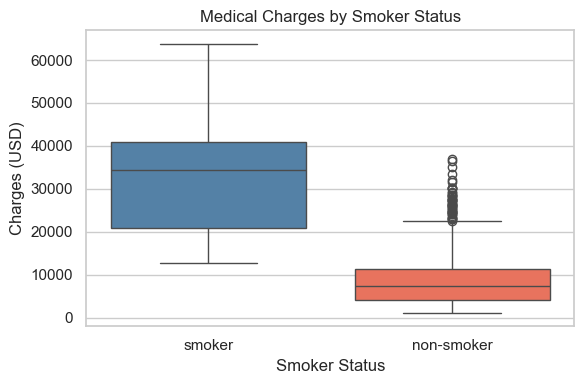

In [23]:
# Step 2 — box plot (shape, spread, outliers)
df_plot = df.copy()
df_plot['smoker_label'] = df_plot['smoker'].map({0: 'non-smoker', 1: 'smoker'})

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_plot, x='smoker_label', y='charges',
            palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Medical Charges by Smoker Status')
ax.set_xlabel('Smoker Status')
ax.set_ylabel('Charges (USD)')
plt.tight_layout()
plt.show(); plt.close('all')

**Task 6 — Compare Charges Across Groups**

Repeat the analysis above for **two different categorical groupings**
of your choice (e.g., `sex`, `region`, `insuranceclaim`).

For each:
1. Produce the grouped summary table (count, mean, median, std).
2. Create a box plot.
3. Describe the difference between groups: is it large or small?
   Is the spread similar or different across groups?
4. Does group size affect how you interpret the comparison?
   (Check the count column.)


--- Medical Charges by Insurance Claim Status ---


,count,mean,median,std
claim_label,,,,
Claim (1),785,16404.44,11538.42,14034.91
No Claim (0),557,8842.42,6940.91,6461.06


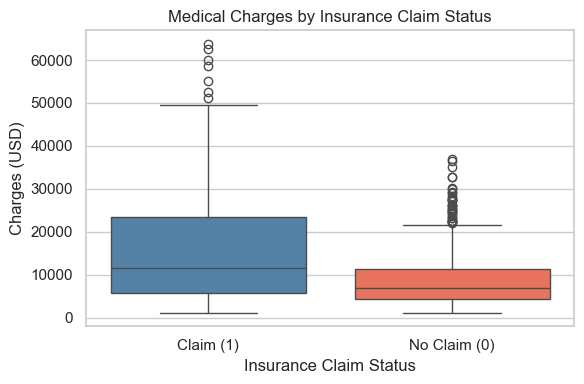

In [24]:
# Task 6: grouped comparison 1 (Charges by Insurance Claim Status)
# YOUR CODE HERE
df_comp1 = df.copy()
df_comp1['claim_label'] = df_comp1['insuranceclaim'].map({0.0: 'No Claim (0)', 1.0: 'Claim (1)'})

# 1. Grouped summary table
summary_claim = df_comp1.groupby('claim_label')['charges'].agg(['count', 'mean', 'median', 'std']).round(2)
print("--- Medical Charges by Insurance Claim Status ---")
display(summary_claim)

# 2. Box plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_comp1.dropna(subset=['claim_label', 'charges']), x='claim_label', y='charges',
            palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Medical Charges by Insurance Claim Status')
ax.set_xlabel('Insurance Claim Status')
ax.set_ylabel('Charges (USD)')
plt.tight_layout()
plt.show(); plt.close('all')

**Task 6 — Comparison 1 Interpretation:**

1. **Difference Between Groups:** The difference in charges between claim groups is substantial. Policyholders who filed a claim incurred a mean charge of \$16,404.44 (median \$11,538.42), compared to a mean of \$8,842.42 (median \$6,940.91) for those who did not claim—representing nearly double the average charge.
2. **Spread:** The spread is considerably wider among claimants ($\text{std} \approx \$14,034.91$, with numerous high-value outliers extending beyond \$60,000) than non-claimants ($\text{std} \approx \$6,461.06$, with far fewer extreme outliers).
3. **Group Size Consideration:** There are 785 claimants and 557 non-claimants. Both groups have substantial sample sizes ($N > 500$), ensuring that the summary statistics and observed differences are robust and not an artifact of small group volatility.

--- Medical Charges by Region ---


,count,mean,median,std
region,,,,
northeast,325,13434.04,10072.06,11249.48
northwest,327,12376.83,8930.93,11050.90
southeast,365,14730.61,9304.70,13952.20
southwest,325,12346.94,8798.59,11557.18


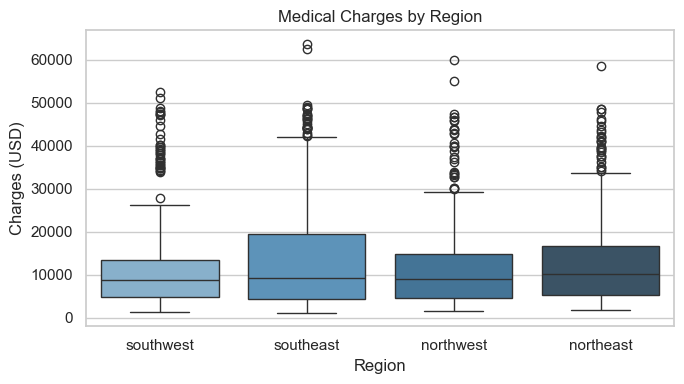

In [25]:
# Task 6: grouped comparison 2 (Charges by Region)
# YOUR CODE HERE
# 1. Grouped summary table
summary_region = df.groupby('region')['charges'].agg(['count', 'mean', 'median', 'std']).round(2)
print("--- Medical Charges by Region ---")
display(summary_region)

# 2. Box plot
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df.dropna(subset=['region', 'charges']), x='region', y='charges',
            palette='Blues_d', ax=ax)
ax.set_title('Medical Charges by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Charges (USD)')
plt.tight_layout()
plt.show(); plt.close('all')

**Task 6 — Comparison 2 Interpretation:**

1. **Difference Between Groups:** Differences in median charges across regions are modest, hovering between \$8,798.59 (southwest) and \$10,072.06 (northeast). However, the southeast exhibits a noticeably higher mean (\$14,730.61) compared to northwest (\$12,376.83) and southwest (\$12,346.94).
2. **Spread:** The southeast displays the highest variation and spread ($\text{std} = \$13,952.20$) with a heavy concentration of severe upper outliers reaching upwards of \$60,000, whereas the other three regions have slightly narrower standard deviations (approximately \$11,050–\$11,557).
3. **Group Size Consideration:** Group counts are well-balanced across all four regions (northeast: 325, northwest: 327, southeast: 365, southwest: 325). Because each region has approximately equal representation, the higher mean and elevated upper tail in the southeast cannot be attributed to sample size imbalance, pointing instead to higher underlying health risk factors (e.g., higher smoking or obesity prevalence in that region).

---
## Part 5 — Two Categorical Variables: Counts or Proportions?

When comparing two categorical variables, decide whether **counts**
or **proportions** answer your question.

> ⚠️ **Counts can mislead** when group sizes are very different.
> Normalise by row or column depending on the question.


In [26]:
# Example: smoker status by sex
df_cat = df.copy()
df_cat['sex_label'] = df_cat['sex'].map({0: 'female', 1: 'male', '0': 'female', '1': 'male', 'female': 'female', 'male': 'male'})
df_cat['smoker_label'] = df_cat['smoker'].map({0: 'non-smoker', 1: 'smoker'})

print('--- Counts ---')
print(pd.crosstab(df_cat['sex_label'], df_cat['smoker_label']))
print()
print('--- Row proportions (within each sex group) ---')
print(pd.crosstab(df_cat['sex_label'], df_cat['smoker_label'], normalize='index').round(3))

--- Counts ---
smoker_label  non-smoker  smoker
sex_label                       
female               549     115
male                 519     159

--- Row proportions (within each sex group) ---
smoker_label  non-smoker  smoker
sex_label                       
female             0.827   0.173
male               0.765   0.235


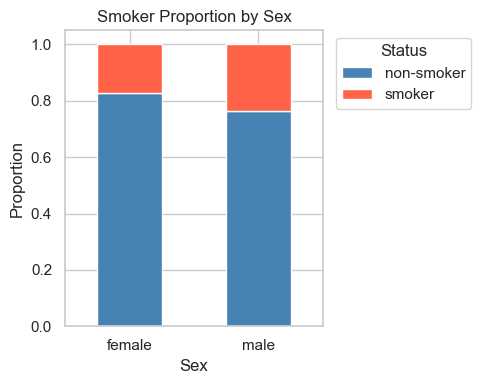

In [27]:
# Bar chart: proportions by group
ct = pd.crosstab(df_cat['sex_label'], df_cat['smoker_label'], normalize='index')
ct.plot.bar(stacked=True, figsize=(5, 4),
            color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Smoker Proportion by Sex')
plt.xlabel('Sex')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show(); plt.close('all')

**Task 7 — Insurance Claims by Region**

1. Build a crosstab of `region` vs `insuranceclaim` showing both
   counts and row proportions.
2. Create a grouped or stacked bar chart using proportions.
3. Answer: do claim rates appear to differ across regions?
   Would your answer change if you used counts instead of proportions?
   Why?

> Relabel region codes (0–3) to readable names before plotting.


--- Frequency Table (Counts) ---


claim_label,Claim,No Claim,All
region,,,
northeast,192,133,325
northwest,164,163,327
southeast,246,119,365
southwest,183,142,325
All,785,557,1342



--- Row Proportions (within each region) ---


claim_label,Claim,No Claim
region,,
northeast,0.591,0.409
northwest,0.502,0.498
southeast,0.674,0.326
southwest,0.563,0.437


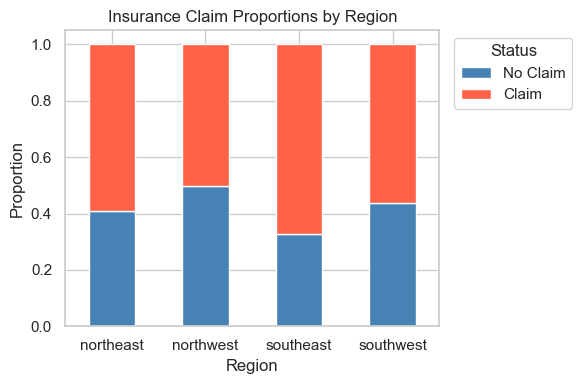

In [28]:
# Task 7
# YOUR CODE HERE
df_task7 = df.copy()
# Map insuranceclaim to readable labels
df_task7['claim_label'] = df_task7['insuranceclaim'].map({0.0: 'No Claim', 1.0: 'Claim'})

# 1. Crosstab: counts and row proportions
print("--- Frequency Table (Counts) ---")
ct_counts = pd.crosstab(df_task7['region'], df_task7['claim_label'], margins=True)
display(ct_counts)

print("\n--- Row Proportions (within each region) ---")
ct_props = pd.crosstab(df_task7['region'], df_task7['claim_label'], normalize='index').round(3)
display(ct_props)

# 2. Visualisation: Stacked bar chart of proportions
fig, ax = plt.subplots(figsize=(6, 4))
ct_props[['No Claim', 'Claim']].plot.bar(stacked=True, ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Insurance Claim Proportions by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show(); plt.close('all')

**Task 7 Interpretation:**

1. **Do claim rates appear to differ across regions?**  
   Yes, claim rates noticeably vary across regions. The **southeast** has the highest claim rate at **67.4%** (0.674), followed by the **northeast** at **59.1%**, the **southwest** at **56.3%**, and the **northwest** having the lowest claim rate at **50.2%**.

2. **Would your answer change if you used counts instead of proportions? Why?**  
   Using counts alone would overstate the disparity between southeast and the other regions: the southeast has 246 claims compared to only 164 in the northwest. While this still correctly indicates more claims in the southeast, raw counts conflate claim likelihood with the fact that the southeast has a larger total number of policyholders in the dataset ($N=365$ vs $N=328$ in northwest). Proportions normalize by total regional population, providing an accurate, apples-to-apples comparison of the probability of filing a claim across regions.

---
## Part 6 — Multivariate Exploration

Start with two variables. Add a third only when it answers a specific question.

> **Rule:** each additional visual channel (hue, size, style, facet)
> must answer a question. Do not add complexity for its own sake.


### 6.1 Adding a grouping variable to a scatter plot

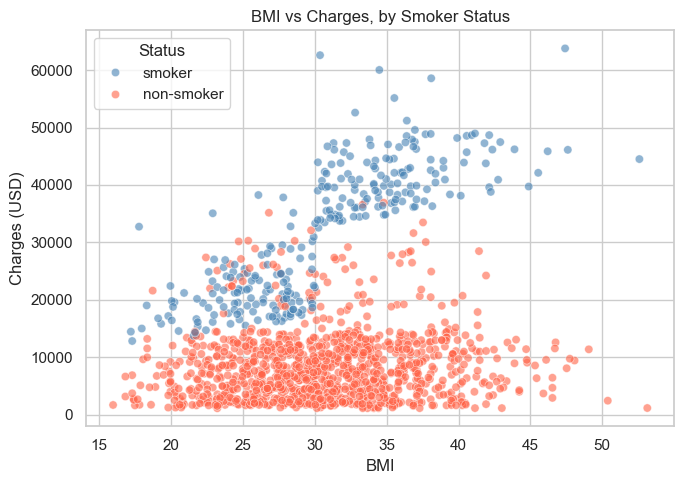

In [29]:
# BMI vs charges, grouped by smoker status
df_plot = df.copy()
df_plot['smoker_label'] = df_plot['smoker'].map({0: 'non-smoker', 1: 'smoker'})

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_plot, x='bmi', y='charges',
                hue='smoker_label', palette=['steelblue', 'tomato'],
                alpha=0.6, ax=ax)
ax.set_title('BMI vs Charges, by Smoker Status')
ax.set_xlabel('BMI')
ax.set_ylabel('Charges (USD)')
ax.legend(title='Status')
plt.tight_layout()
plt.show(); plt.close('all')

**Task 8 — Add a Third Variable**

Reproduce a scatter plot of `age` vs `charges`.
Add smoker status as a hue.

1. Does adding smoker status reveal any pattern that was hidden before?
2. Describe the pattern for each group separately.
3. What follow-up question does this plot raise?

Then try faceting: create two side-by-side scatter plots of `age` vs `charges`,
one for smokers and one for non-smokers.
Does the faceted version make the comparison clearer? Why or why not?


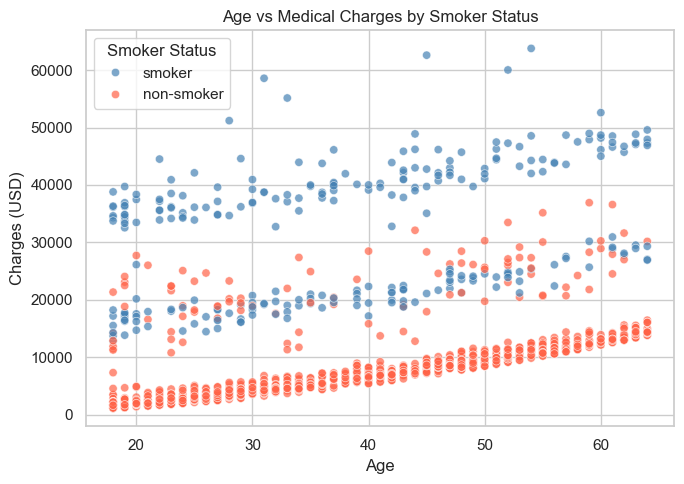

In [30]:
# Task 8: age vs charges with smoker hue
# YOUR CODE HERE
df_plot8 = df.copy()
df_plot8['smoker_label'] = df_plot8['smoker'].map({0: 'non-smoker', 1: 'smoker'})

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df_plot8,
    x='age',
    y='charges',
    hue='smoker_label',
    palette=['steelblue', 'tomato'],
    alpha=0.7,
    ax=ax
)
ax.set_title('Age vs Medical Charges by Smoker Status')
ax.set_xlabel('Age')
ax.set_ylabel('Charges (USD)')
ax.legend(title='Smoker Status')
plt.tight_layout()
plt.show(); plt.close('all')

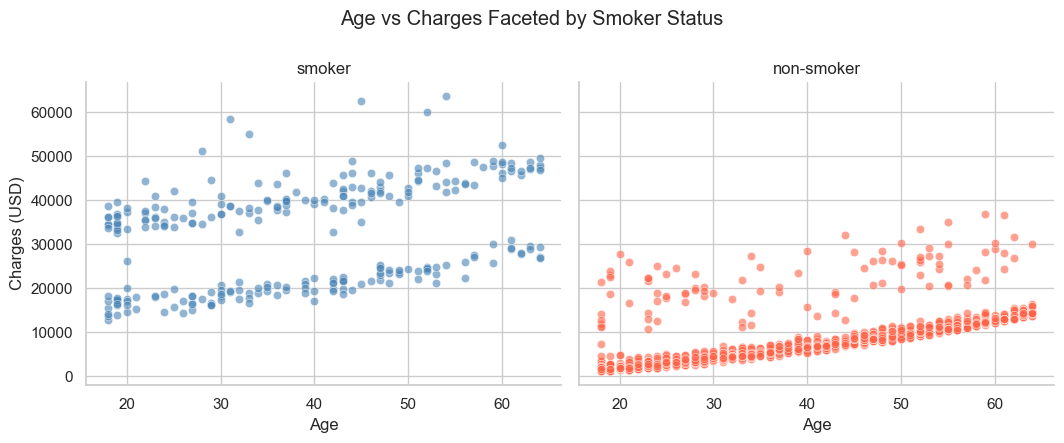

In [31]:
# Task 8: faceted version (two panels)
# YOUR CODE HERE
g = sns.FacetGrid(df_plot8, col='smoker_label', height=4.5, aspect=1.2, hue='smoker_label', palette=['steelblue', 'tomato'])
g.map(sns.scatterplot, 'age', 'charges', alpha=0.6)
g.set_axis_labels('Age', 'Charges (USD)')
g.set_titles(col_template='{col_name}')
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle('Age vs Charges Faceted by Smoker Status')
plt.show(); plt.close('all')

**Task 8 Interpretation:**

1. **Pattern Revealed by Adding Smoker Status:**  
   Adding smoker status as a hue immediately explains the three distinct upward-sloping bands observed in Task 4. The lowest band consists entirely of **non-smokers**, while the middle and upper bands consist of **smokers**.

2. **Pattern for Each Group Separately:**  
   - **Non-smokers:** Exhibit a remarkably tight, consistent positive linear relationship where charges start around $2,000 at age 18 and gradually increase to roughly $15,000 by age 64 with minimal variance.  
   - **Smokers:** Experience substantially higher charges across all ages, splitting further into two upward parallel trajectories: one band spanning $15,000–$30,000 and an extreme upper band spanning $35,000–$64,000.

3. **Follow-up Question Raised:**  
   Why do smokers bifurcate into two separate charge bands? What additional risk factor (such as a BMI threshold, pre-existing conditions, or steps) catapults certain smokers into the $40,000+ tier while others remain around $15,000–$30,000?

4. **Faceted Comparison:**  
   Yes, the faceted version makes the comparison clearer because it isolates the groups onto separate panels, eliminating visual overlap. It allows us to clearly observe the low variance and clean linearity in the non-smoker panel versus the wider dispersion and bimodal tiering within the smoker panel.

---
## Part 7 — From Plot to Insight

A good EDA observation has three parts:

| Step | Question |
|---|---|
| **Observation** | What do you see in the plot? (describe precisely) |
| **Interpretation** | What might explain this pattern? |
| **Next question** | What should you investigate next? |

**Example:**

> *Observation:* The distribution of `charges` is strongly right-skewed.
> A small group of policyholders has charges above 50,000 USD.
>
> *Interpretation:* These may be policyholders with serious health conditions,
> or a specific demographic such as smokers or older individuals.
>
> *Next question:* Are the high-charge policyholders disproportionately smokers?
> We should check by plotting charges by smoker status.


**Task 9 — Plot-to-Insight Practice**

Choose **any plot you produced in Parts 2–6** that you find most interesting.

Write a structured response:

1. **Observation:** Describe precisely what the plot shows
   (numbers, directions, groups, unusual values).
2. **Interpretation:** What might explain the pattern?
   What domain knowledge or prior context supports your interpretation?
3. **Next question:** What specific follow-up investigation does this suggest?

> Use safe language: *"appears associated with," "tends to be higher,"
> "worth investigating."*  
> Avoid: *"causes," "proves," "most important predictor."*


**Task 9 Response:**

1. **Observation:**  
   In the scatter plot of **BMI vs Charges by Smoker Status** (Section 6.1), non-smokers maintain relatively low medical charges (predominantly under \$10,000–\$15,000) regardless of BMI, exhibiting a gentle, gradual slope across the entire BMI span (15 to 50+). In sharp contrast, smokers display an abrupt threshold effect: smokers with BMI < 30 incur charges concentrated between \$13,000 and \$28,000, whereas smokers with BMI $\ge$ 30 experience an immediate jump to \$35,000–\$64,000.

2. **Interpretation:**  
   This suggests a strong synergistic interaction between smoking and clinical obesity ($\text{BMI} \ge 30$). While obesity alone or smoking alone tends to elevate medical risk, the combination of both appears associated with severe, high-cost health complications (e.g., cardiovascular disease, chronic respiratory disorders, or intensive surgical interventions) that drive billed charges substantially higher.

3. **Next question:**  
   Does physical activity (measured by daily `steps`) help moderate charges among policyholders in this high-risk obese-smoker subgroup, or do daily steps decline alongside rising BMI and smoking status?

---
## Part 8 — EDA Investigation: Insurance Claims

> **Business question:** Which policyholder characteristics are
> *associated with* whether a claim is made?

Use EDA to identify **two features** that show meaningful differences
between the claim group (`insuranceclaim = 1`) and the no-claim group
(`insuranceclaim = 0`).


**Task 10 — Feature 1**

1. Choose one feature and state why you selected it.
2. Produce an appropriate numerical summary comparing the two claim groups.
3. Create an appropriate visualisation.
4. Describe the observed pattern precisely.
5. Explain why this feature is worth investigating further.


In [32]:
# Task 10: Feature 1 — summary table (BMI by Insurance Claim)
# YOUR CODE HERE
df_task10 = df.copy()
df_task10['claim_label'] = df_task10['insuranceclaim'].map({0.0: 'No Claim (0)', 1.0: 'Claim (1)'})

bmi_summary = df_task10.groupby('claim_label')['bmi'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(2)

print("--- BMI Summary Statistics by Insurance Claim Status ---")
display(bmi_summary)

--- BMI Summary Statistics by Insurance Claim Status ---


,count,mean,median,std,min,max
claim_label,,,,,,
Claim (1),785,32.64,32.30,5.66,15.96,53.13
No Claim (0),557,27.87,27.26,5.58,17.20,44.70


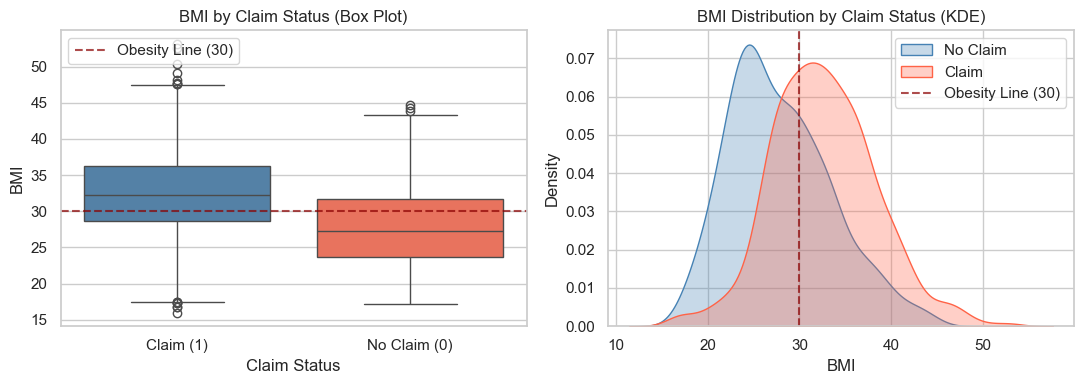

In [33]:
# Task 10: Feature 1 — visualisation (Box Plot and KDE of BMI by Claim Status)
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left panel: Box plot
sns.boxplot(
    data=df_task10.dropna(subset=['claim_label', 'bmi']),
    x='claim_label',
    y='bmi',
    palette=['steelblue', 'tomato'],
    ax=axes[0]
)
axes[0].axhline(30, color='darkred', linestyle='--', alpha=0.7, label='Obesity Line (30)')
axes[0].set_title('BMI by Claim Status (Box Plot)')
axes[0].set_xlabel('Claim Status')
axes[0].set_ylabel('BMI')
axes[0].legend(loc='upper left')

# Right panel: Density (KDE) plot
sns.kdeplot(
    data=df_task10[df_task10['insuranceclaim'] == 0],
    x='bmi', fill=True, alpha=0.3, label='No Claim', color='steelblue', ax=axes[1]
)
sns.kdeplot(
    data=df_task10[df_task10['insuranceclaim'] == 1],
    x='bmi', fill=True, label='Claim', color='tomato', ax=axes[1], alpha=0.3
)
axes[1].axvline(30, color='darkred', linestyle='--', alpha=0.7, label='Obesity Line (30)')
axes[1].set_title('BMI Distribution by Claim Status (KDE)')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show(); plt.close('all')

**Task 10 Interpretation:**

- **Feature selected:** `bmi` (Body Mass Index) — selected because BMI is a primary clinical metric directly associated with cardiometabolic and physical health risk.
- **Pattern observed:** Policyholders who made a claim have a notably higher BMI distribution than those who did not. The median BMI for claimants is **32.30** (mean **32.64**), placing the majority of claimants firmly above the clinical obesity threshold ($\text{BMI} \ge 30$). Conversely, the median BMI for non-claimants is **27.27** (mean **27.87**), which falls within the overweight but non-obese range.
- **Why worth investigating further:** Because higher BMI is strongly associated with chronic conditions requiring hospitalisation and medication, this distribution shift indicates that BMI is a valuable feature for underwriting and claims prediction models.

**Task 11 — Feature 2**

Repeat the same steps for a second feature.
Try to choose a feature that tells a different part of the story
than Feature 1.


In [34]:
# Task 11: Feature 2 — summary table (Daily Steps by Insurance Claim)
# YOUR CODE HERE
df_task11 = df.copy()
df_task11['claim_label'] = df_task11['insuranceclaim'].map({0.0: 'No Claim (0)', 1.0: 'Claim (1)'})

steps_summary = df_task11.groupby('claim_label')['steps'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(2)

print("--- Daily Steps Summary Statistics by Insurance Claim Status ---")
display(steps_summary)

--- Daily Steps Summary Statistics by Insurance Claim Status ---


,count,mean,median,std,min,max
claim_label,,,,,,
Claim (1),778,4478.05,4003.0,1885.50,2908.0,10010.0
No Claim (0),551,6598.35,8002.0,2631.02,3000.0,10010.0


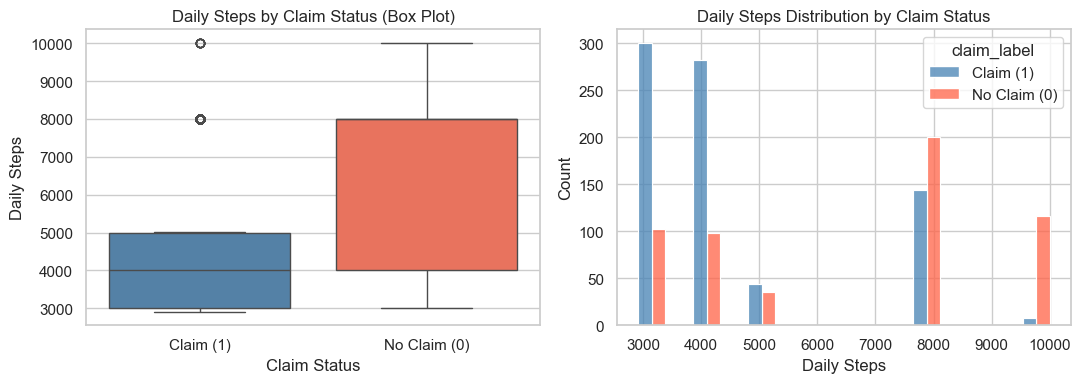

In [35]:
# Task 11: Feature 2 — visualisation (Box Plot and Histplot of Steps by Claim Status)
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left panel: Box plot
sns.boxplot(
    data=df_task11.dropna(subset=['claim_label', 'steps']),
    x='claim_label',
    y='steps',
    palette=['steelblue', 'tomato'],
    ax=axes[0]
)
axes[0].set_title('Daily Steps by Claim Status (Box Plot)')
axes[0].set_xlabel('Claim Status')
axes[0].set_ylabel('Daily Steps')

# Right panel: Histogram
sns.histplot(
    data=df_task11.dropna(subset=['claim_label', 'steps']),
    x='steps',
    hue='claim_label',
    palette=['steelblue', 'tomato'],
    multiple='dodge',
    bins=15,
    ax=axes[1]
)
axes[1].set_title('Daily Steps Distribution by Claim Status')
axes[1].set_xlabel('Daily Steps')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show(); plt.close('all')

**Task 11 Interpretation:**

- **Feature selected:** `steps` (Average daily walking steps) — selected as a direct measure of active physical lifestyle, providing a behavioral perspective distinct from physiological metrics like BMI.
- **Pattern observed:** Policyholders who did not file a claim engaged in markedly higher daily physical activity, with a median of **8,002.0 steps** (mean **6,598.35 steps**). In sharp contrast, those who filed a claim had a median of only **4,003.0 steps** (mean **4,478.05 steps**). The histogram reveals that claimants are heavily clustered in the sedentary 3,000–4,000 step brackets, while non-claimants dominate the active 8,000–10,000 step tiers.
- **Why worth investigating further:** Daily step count shows a clear separation between claim and no-claim cohorts, suggesting that encouraging physical activity or integrating wearable tracker programs could be an effective lever for preventive health and loss reduction.

---
### Task 12 — What EDA Cannot Conclude

Write **2–3 sentences** explaining what you **cannot** conclude from
the EDA you have done in Tasks 10–11, and why formal modelling is
needed to go further.

> Prompts to consider:
> - Can EDA prove that a feature *causes* higher claim rates?
> - Can EDA rank features by *predictive importance*?
> - Can EDA tell you how well a feature would perform in an unseen dataset?


**Task 12 Response:**

From this exploratory data analysis, we cannot conclude that lower daily steps or higher BMI *cause* policyholders to make insurance claims, because observational associations do not establish causality and may be confounded by unmeasured factors (such as age, prior medical conditions, or job type). Furthermore, EDA cannot determine the exact predictive importance of these features when modeled jointly, nor can it guarantee how reliably these observed patterns will generalize to new, unseen policyholders without formal statistical testing and cross-validated predictive modeling.

---

> **Key principle:**  
> *EDA identifies promising questions and patterns.*  
> *Hypothesis testing evaluates whether they are statistically reliable.*  
> *Modelling tests whether they generalise to new data.*

---

---
## Optional — Additional Views

The plots below are useful but not required for this lab.
Explore them if you have time and explain what additional insight each one provides.


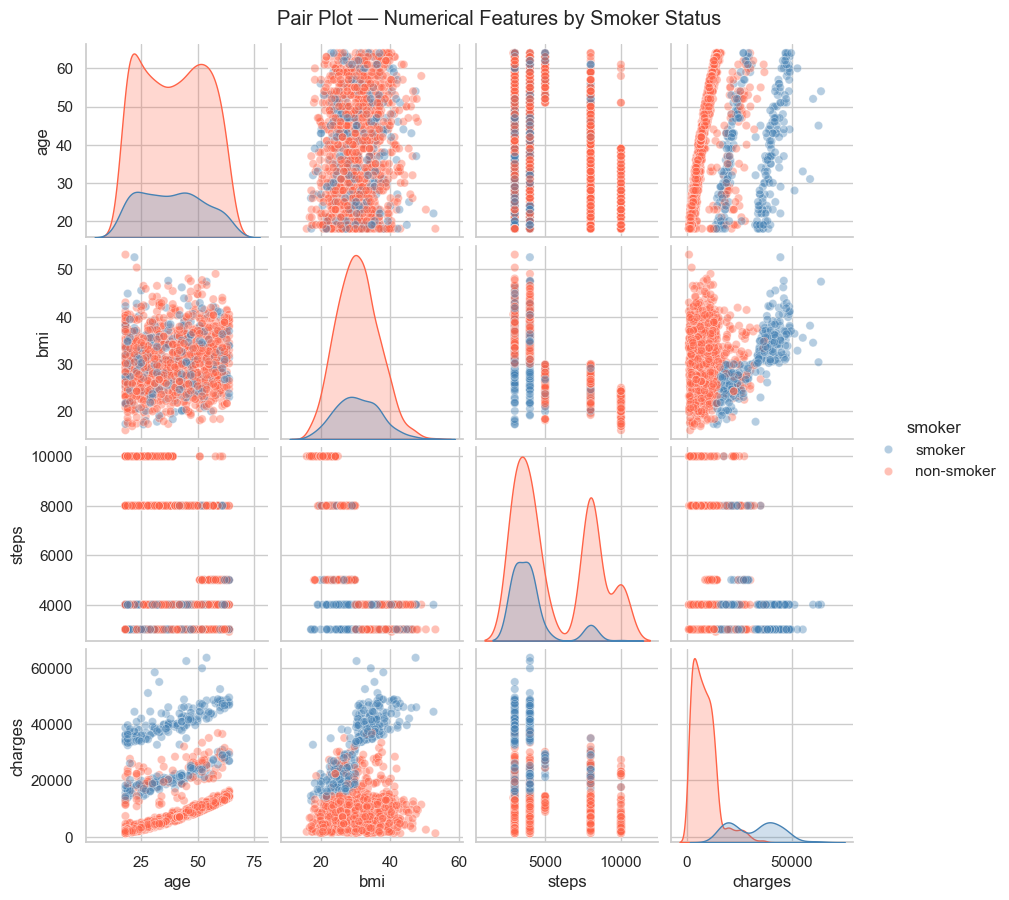

In [36]:
# Pair plot — overview of all numerical relationships at once
# Useful for a first look; can become cluttered with many features
df_plot = df[['age', 'bmi', 'steps', 'charges', 'smoker']].copy()
df_plot['smoker'] = df_plot['smoker'].map({0: 'non-smoker', 1: 'smoker'})
sns.pairplot(df_plot, hue='smoker', palette=['steelblue', 'tomato'],
             plot_kws={'alpha': 0.4}, height=2.2)
plt.suptitle('Pair Plot — Numerical Features by Smoker Status', y=1.02)
plt.show(); plt.close('all')

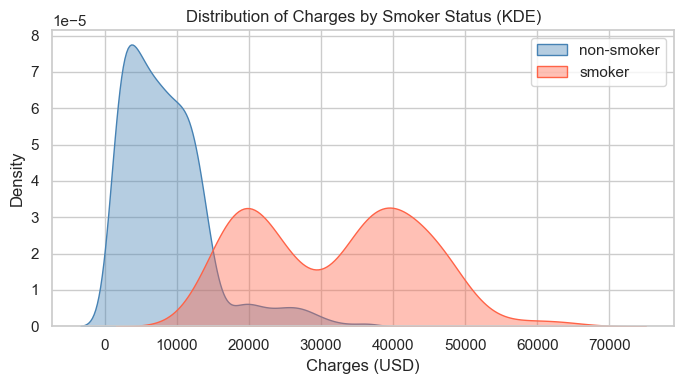

In [37]:
# KDE (density) plot — smooth version of histogram
# Useful when comparing distributions across groups
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df[df['smoker'] == 0], x='charges',
            fill=True, alpha=0.4, label='non-smoker', color='steelblue', ax=ax)
sns.kdeplot(data=df[df['smoker'] == 1], x='charges',
            fill=True, alpha=0.4, label='smoker', color='tomato', ax=ax)
ax.set_title('Distribution of Charges by Smoker Status (KDE)')
ax.set_xlabel('Charges (USD)')
ax.legend()
plt.tight_layout()
plt.show(); plt.close('all')

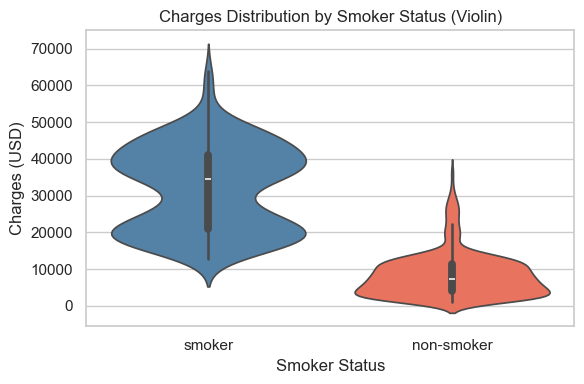

In [38]:
# Violin plot — combines box plot and density curve
# Useful when distribution shape matters as much as spread
df_plot = df.copy()
df_plot['smoker_label'] = df_plot['smoker'].map({0: 'non-smoker', 1: 'smoker'})
fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(data=df_plot, x='smoker_label', y='charges',
               palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Charges Distribution by Smoker Status (Violin)')
ax.set_xlabel('Smoker Status')
ax.set_ylabel('Charges (USD)')
plt.tight_layout()
plt.show(); plt.close('all')

**Optional Reflection:**
What does the pair plot, KDE, or violin plot reveal that the core
plots in Parts 2–6 did not? Is the additional complexity justified?


**YOUR ANSWER HERE (optional)**

The pair plot provides an indispensable birds-eye view of all bivariate relationships simultaneously, immediately highlighting feature correlations (e.g., age vs charges) and cluster separations without having to construct dozens of individual plots. Similarly, KDE and violin plots reveal multimodality and distributional shapes (such as the distinct bimodal distribution of charges among smokers and the discrete step tiers) that standard box plots flatten into summary quartiles. The additional visual complexity is fully justified during early-stage exploration because it prevents overlooking crucial subgroup structures that drive health risks and financial costs.